# **Projet de Fin de Module : Intelligence Artificielle 1**
## **Thème : Analyse Prédictive de l'Espérance de Vie (Global Health Analysis)**

**Réalisé par :**
* **Mohamed KHAYRI**

---

### **1. Introduction et Contexte**
L'espérance de vie est un indicateur multidimensionnel reflétant la qualité de vie et l'efficacité des systèmes de santé mondiaux. Ce projet vise à explorer les déterminants de la longévité humaine en utilisant des techniques d'**Apprentissage Automatique (Machine Learning)**. Notre démarche consiste à modéliser les interactions entre les facteurs économiques, sociaux et sanitaires pour prédire cet indicateur de santé mondiale.

### **2. Description du Jeu de Données (Dataset)**
Les données proviennent de l'**Organisation Mondiale de la Santé (OMS)**. Le jeu de données se compose de :
* **Variable Cible (Target Variable) :** `Life expectancy`.
* **Variables Explicatives (Features) :** 
    * *Santé Publique :* `Adult Mortality`, `infant deaths`, `HIV/AIDS`.
    * *Prévention & Immunisation :* `Polio`, `Hepatitis B`, `Diphtheria`.
    * *Indicateurs Socio-Économiques :* `GDP`, `Total expenditure`, `Schooling`, `Income composition of resources`.
    * *Autres :* `Status`, `BMI`, `Thinness`.

### **3. Objectifs du Projet**
1.  **Analyse Exploratoire (EDA) :** Diagnostiquer la structure des données et identifier les corrélations.
2.  **Ingénierie des Données (Data Engineering) :** Traiter les anomalies et optimiser les variables.
3.  **Modélisation Prédictive :** Implémenter des algorithmes de **Régression Supervisée**.
4.  **Étude Comparative :** Évaluer l'impact du traitement des valeurs aberrantes (Outliers) sur la précision.

### **4. Architecture du Pipeline Machine Learning**
Notre méthodologie suit un flux de travail (Workflow) rigoureux divisé en quatre étapes :

* **Étape 0 : Prétraitement des Données (Data Preprocessing)**
    * Nettoyage, traitement des valeurs manquantes (Imputation), encodage de la variable `Status` et sélection des caractéristiques (Feature Selection).
* **Étape 1 : Préparation à l'Apprentissage (Splitting & Scaling)**
    * Division du dataset en ensembles d'entraînement (Train Set) et de test (Test Set), suivie d'une mise à l'échelle (Feature Scaling).
* **Étape 2 : Modélisation de Référence et Étude Comparative**
    * Entraînement de la Régression Linéaire sur les scénarios A (complet) et B (nettoyé) pour validation de la stratégie.
* **Étape 3 : Modèles Avancés et Optimisation**
    * Implémentation et réglage des hyperparamètres pour les modèles KNN et Arbre de Décision (Decision Tree).
* **Étape 4 : Synthèse et Comparaison Finale**
    * Évaluation comparative des performances globales (R² et RMSE) et sélection du modèle champion pour la prédiction finale.
    

# **Étape 0 : Prétraitement des Données (Data Preprocessing)**

Cette étape est le pilier de notre projet. Elle consiste à transformer des données brutes, souvent incomplètes ou bruitées, en un dataset propre et exploitable par les algorithmes de Machine Learning. La qualité de nos prédictions dépend directement de la rigueur appliquée lors de cette phase.

#### **Objectifs de cette étape :**
1. **Nettoyage et Diagnostic :** Identifier les types de données et traiter les incohérences.
2. **Gestion des Valeurs Manquantes (Imputation) :** Combler les lacunes statistiques de manière intelligente.
3. **Ingénierie des Caractéristiques (Feature Engineering) :** Convertir les données textuelles et optimiser la sélection des variables (Features).

---
### **I. Mise en Place de l'Environnement et Chargement des Données**
##### Dans cette étape, nous allons importer les bibliothèques Python indispensables pour la manipulation des données, la visualisation et le Machine Learning. Ensuite, nous chargerons le dataset pour un premier aperçu.
---

In [1]:
# 1. Importation des bibliothèques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error

# Ignorer les avertissements pour plus de clarté
warnings.filterwarnings('ignore')

# Configuration de la visualisation
%matplotlib inline
sns.set(style="whitegrid")

In [2]:
# 2. Chargement du dataset
df = pd.read_csv('Life Expectancy Data.csv')

# 3. Aperçu des premières lignes
print("Aperçu des 5 premières lignes du dataset :")
display(df.head())

Aperçu des 5 premières lignes du dataset :


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


---
## **II. Exploration et Diagnostic des Données**

Avant d'entamer la phase de préparation, il est primordial d'effectuer un diagnostic initial pour comprendre la structure technique et statistique du dataset. Nous utilisons pour cela deux fonctions fondamentales de Pandas :

1.  **`df.info()`** : Pour identifier les types de données et quantifier précisément les valeurs manquantes (Missing Values).
2.  **`df.describe()`** : Pour générer un résumé statistique. C'est un outil indispensable pour détecter la dispersion des données et suspecter la présence de valeurs aberrantes (Outliers).
---

In [3]:
# 1. Affichage des informations structurelles
print("--- Structure du Dataset ---")
df.info()

# 2. Résumé statistique des variables numériques
print("\n--- Résumé Statistique ---")
display(df.describe())

--- Structure du Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int6

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938.000000,2928.000000,2928.000000,2938.000000,2744.000000,2938.000000,2385.000000,2938.000000,2904.000000,2938.000000,2919.000000,2712.00000,2919.000000,2938.000000,2490.000000,2.286000e+03,2904.000000,2904.000000,2771.000000,2775.000000
mean,2007.518720,69.224932,164.796448,30.303948,4.602861,738.251295,80.940461,2419.592240,38.321247,42.035739,82.550188,5.93819,82.324084,1.742103,7483.158469,1.275338e+07,4.839704,4.870317,0.627551,11.992793
std,4.613841,9.523867,124.292079,117.926501,4.052413,1987.914858,25.070016,11467.272489,20.044034,160.445548,23.428046,2.49832,23.716912,5.077785,14270.169342,6.101210e+07,4.420195,4.508882,0.210904,3.358920
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.37000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2004.000000,63.100000,74.000000,0.000000,0.877500,4.685343,77.000000,0.000000,19.300000,0.000000,78.000000,4.26000,78.000000,0.100000,463.935626,1.957932e+05,1.600000,1.500000,0.493000,10.100000
50%,2008.000000,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,43.500000,4.000000,93.000000,5.75500,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,2012.000000,75.700000,228.000000,22.000000,7.702500,441.534144,97.000000,360.250000,56.200000,28.000000,97.000000,7.49250,97.000000,0.800000,5910.806335,7.420359e+06,7.200000,7.200000,0.779000,14.300000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.60000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


---
### **Observations du Diagnostic Initial :**

L'analyse des résultats précédents nous permet de dresser le constat suivant :

* **Variables Catégorielles :** Le dataset contient des variables de type `object` (`Country` et `Status`). Cela indique qu'un **Encodage** sera nécessaire pour les intégrer dans nos modèles mathématiques.
* **Données Manquantes :** Nous observons des lacunes importantes dans plusieurs colonnes, notamment `Life expectancy`, `Hepatitis B` et `GDP`. Cela justifie l'étape d'**Imputation** que nous détaillerons plus loin.
* **Asymétrie et Dispersion :** Les statistiques de `df.describe()` montrent des écarts types très élevés pour `GDP` et `Population`. De plus, la différence entre la moyenne (mean) et la médiane (50%) suggère des distributions asymétriques. Ce constat orientera notre choix entre la moyenne et la médiane lors du traitement des données.
* **Présence d'Outliers :** Les valeurs maximales de certaines colonnes semblent très éloignées des quartiles supérieurs, ce qui laisse présager la présence de valeurs aberrantes nécessitant une attention particulière.

  **Ce diagnostic confirme que le dataset nécessite un nettoyage rigoureux avant toute modélisation.**
---

---
### **III. Nettoyage Initial (Data Cleaning)**

Le nettoyage des données est une étape déterminante pour la qualité des entrées. Dans cette section, nous nous concentrons sur la normalisation de la structure du dataset :

1. **Rectification des noms des colonnes** : Suppression des espaces inutiles (leading/trailing spaces) pour éviter les erreurs d'appel des variables.
2. **Vérification de l'intégrité** : Identification précise du volume de données manquantes avant l'étape d'imputation.
---

In [4]:
# 1. Vérification des colonnes (Important pour ce dataset !)
print("\nListe des colonnes initiales :")
print(df.columns.tolist())
# 2. Nettoyage des noms de colonnes (Suppression des espaces blancs)
df.columns = df.columns.str.strip()
print("Noms des colonnes après nettoyage :=======================")
print(df.columns.tolist())

# 2. Identification des valeurs manquantes
print("\nNombre de valeurs manquantes par colonne :")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])


Liste des colonnes initiales :
['Country', 'Year', 'Status', 'Life expectancy ', 'Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles ', ' BMI ', 'under-five deaths ', 'Polio', 'Total expenditure', 'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population', ' thinness  1-19 years', ' thinness 5-9 years', 'Income composition of resources', 'Schooling']
Noms des colonnes après nettoyage :=======================
['Country', 'Year', 'Status', 'Life expectancy', 'Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure', 'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness  1-19 years', 'thinness 5-9 years', 'Income composition of resources', 'Schooling']

Nombre de valeurs manquantes par colonne :
Life expectancy                     10
Adult Mortality                     10
Alcohol                            194
Hepatitis B                        553
BMI   

---
### **IV. Analyse de la Distribution et Stratégie d'Imputation**

Le traitement des valeurs manquantes ne doit pas être arbitraire. Pour garantir la précision de nos modèles futurs, nous adoptons une approche basée sur la forme statistique de chaque variable :

1. **Analyse de l'Asymétrie (Skewness) :**

   - Si une variable suit une distribution normale ($|Skewness| \leq 1$), la **Moyenne** est l'estimateur idéal.
   - Si une variable est fortement biaisée ($|Skewness| > 1$), la **Médiane** est préférée car elle est robuste aux valeurs aberrantes (outliers).

2. **Visualisation :** Nous allons d'abord visualiser les distributions pour confirmer nos choix techniques.
---

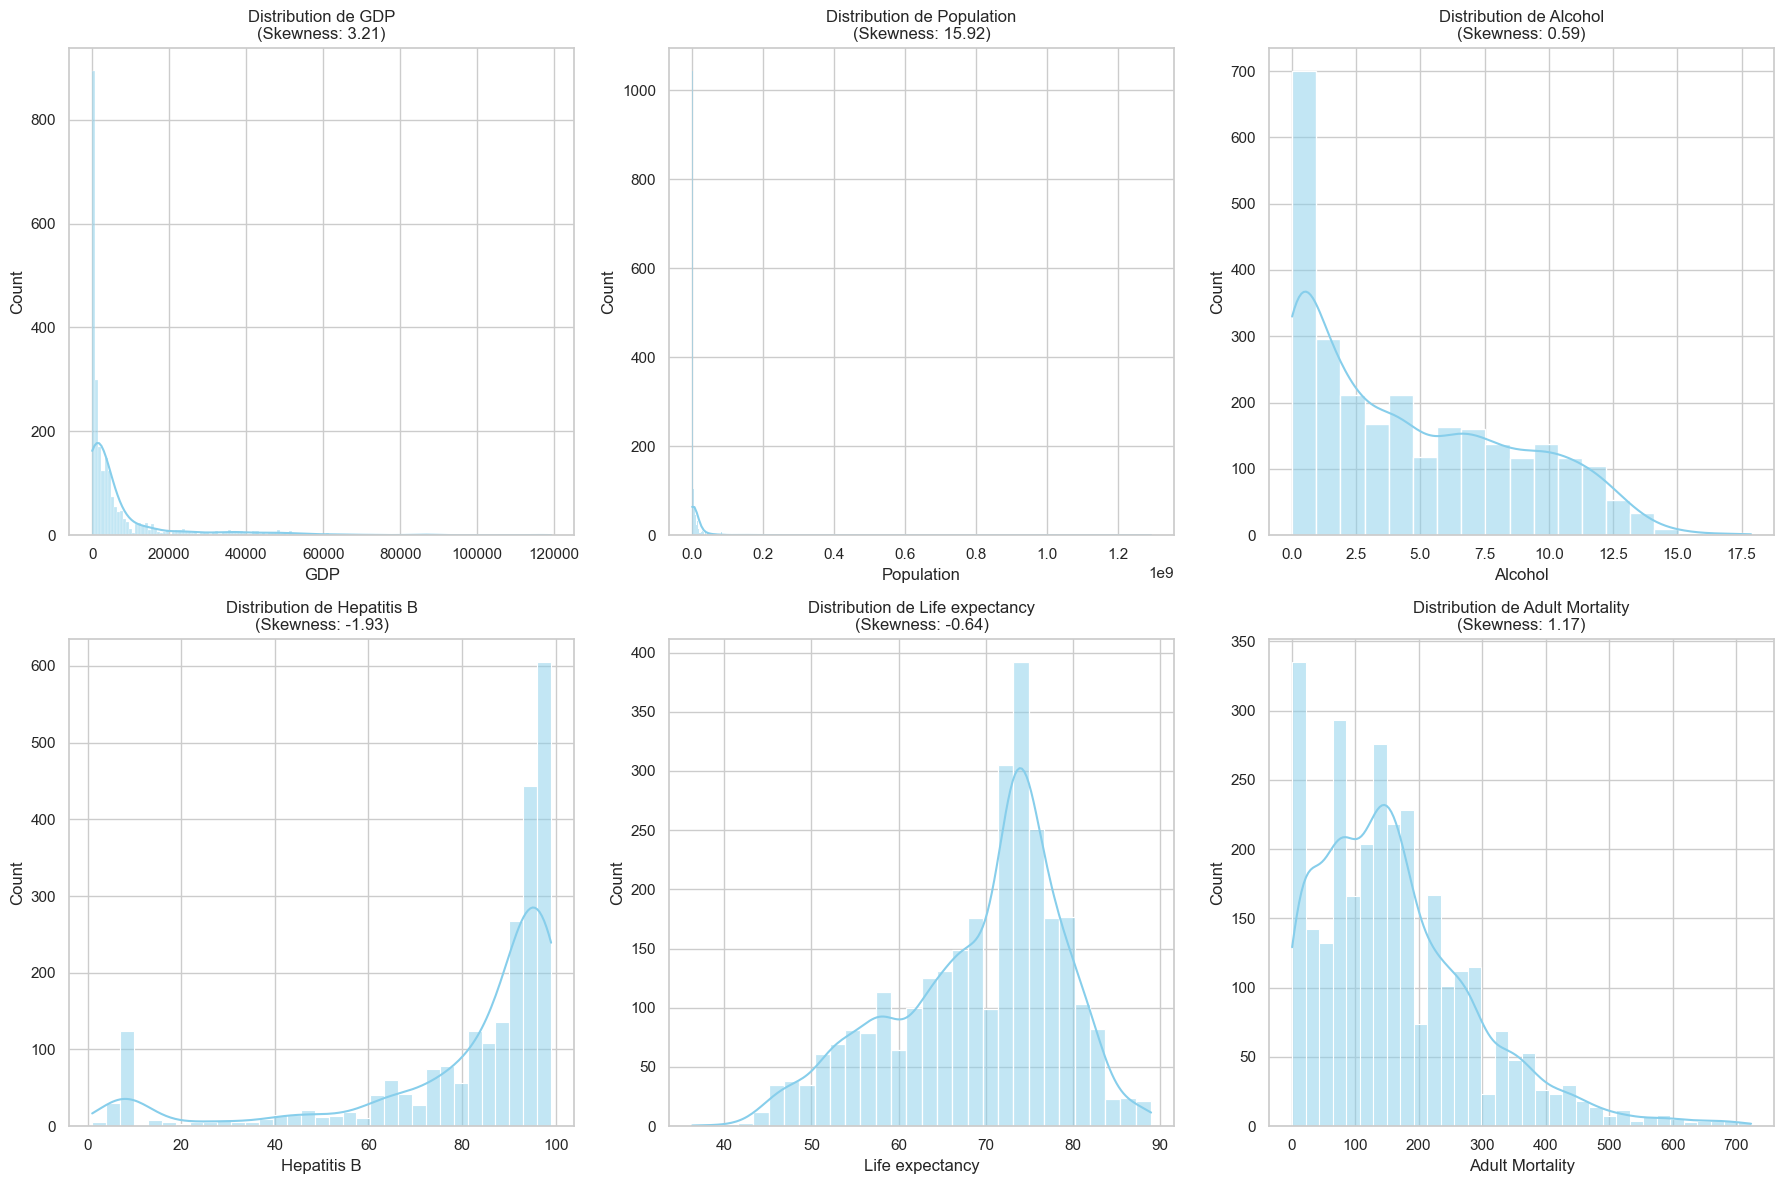

Coefficients de Skewness pour toutes les colonnes numériques :
Year                               -0.006409
Life expectancy                    -0.638605
Adult Mortality                     1.174369
infant deaths                       9.786963
Alcohol                             0.589563
percentage expenditure              4.652051
Hepatitis B                        -1.930845
Measles                             9.441332
BMI                                -0.219312
under-five deaths                   9.495065
Polio                              -2.098053
Total expenditure                   0.618686
Diphtheria                         -2.072753
HIV/AIDS                            5.396112
GDP                                 3.206655
Population                         15.916236
thinness  1-19 years                1.711471
thinness 5-9 years                  1.777424
Income composition of resources    -1.143763
Schooling                          -0.602437
dtype: float64


In [5]:
# Sélection des colonnes avec le plus de valeurs manquantes pour analyse
cols_prioritaires = ['GDP', 'Population', 'Alcohol', 'Hepatitis B', 'Life expectancy', 'Adult Mortality']

# Visualisation des distributions
plt.figure(figsize=(18, 12))
for i, col in enumerate(cols_prioritaires, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col].dropna(), kde=True, color="skyblue")
    plt.title(f'Distribution de {col}\n(Skewness: {df[col].skew():.2f})')

plt.tight_layout()
plt.show()

# Affichage des valeurs exactes de Skewness
print("Coefficients de Skewness pour toutes les colonnes numériques :")
print(df.select_dtypes(include=[np.number]).skew())

---
#### **Analyse des Résultats :**
L'analyse visuelle et le calcul du Skewness révèlent que :
* Des variables comme **`GDP`** et **`Population`** présentent un biais extrême (Skewness > 3). L'utilisation de la médiane est ici indispensable.
* La variable cible **`Life expectancy`** est relativement équilibrée.
* Pour les colonnes de vaccination (ex: **`Polio`**), le biais est négatif, indiquant une concentration vers les valeurs élevées.

  **En conséquence, nous allons utiliser le **`SimpleImputer`** de Scikit-Learn avec deux stratégies différenciées.**
---

In [6]:
# 1. Identification des colonnes selon la stratégie
numeric_cols = df.select_dtypes(include=[np.number]).columns
cols_mediane = [col for col in numeric_cols if abs(df[col].skew()) > 1]
cols_moyenne = [col for col in numeric_cols if abs(df[col].skew()) <= 1]

# 2. Initialisation des Imputers
imputer_mediane = SimpleImputer(strategy='median')
imputer_moyenne = SimpleImputer(strategy='mean')

# 3. Application de l'imputation (Fit & Transform)
df[cols_mediane] = imputer_mediane.fit_transform(df[cols_mediane])
df[cols_moyenne] = imputer_moyenne.fit_transform(df[cols_moyenne])

# 4. Traitement final de la variable cible
# On supprime les lignes où l'espérance de vie est manquante (donnée cruciale)
df.dropna(subset=['Life expectancy'], inplace=True)

print("Imputation terminée avec succès.")
print("Nombre de valeurs manquantes restantes dans le dataset :", df.isnull().sum().sum())

Imputation terminée avec succès.
Nombre de valeurs manquantes restantes dans le dataset : 0


---
### **V. Encodage des Variables Catégorielles**

Avant d'analyser les corrélations, nous devons traiter les deux variables textuelles du dataset :

* **Variable `Status` :** Étant une variable binaire (`Developed` / `Developing`), elle est essentielle pour le modèle. Nous allons la transformer en valeurs numériques (0 et 1).
* **Variable `Country` :** Cette variable présente une cardinalité élevée (193 pays). L'utilisation du *One-Hot Encoding* créerait un trop grand nombre de colonnes, tandis que le *Label Encoding* introduirait une hiérarchie sans sens mathématique. Pour ces raisons, nous prévoyons de la **supprimer** ultérieurement, mais nous la gardons temporairement pour l'étape d'exploration.

  **Cette étape conclut la phase d'encodage des données.**
---

In [7]:
# Transformation de la variable Status
# Developing = 0, Developed = 1
df['Status'] = df['Status'].replace({'Developing': 0, 'Developed': 1})

print("Encodage de la variable 'Status' effectué avec succès.")
display(df[['Status']].head())
print(df['Status'].value_counts())

Encodage de la variable 'Status' effectué avec succès.


,Status
0,0
1,0
2,0
3,0
4,0


Status
0    2426
1     512
Name: count, dtype: int64


---
### **VI. Analyse Exploratoire : Étude de Corrélation**

Après le nettoyage des données, cette étape vise à comprendre les relations entre les différents indicateurs et notre variable cible : l'espérance de vie (**Life expectancy**). 

#### **Objectifs de l'analyse :**
1. **Sélection des variables (Feature Selection) :** Identifier les facteurs qui influencent le plus la longévité (corrélations fortes).
2. **Détection de la Multicolinéarité :** Repérer les variables qui fournissent la même information (redondance) afin de simplifier le futur modèle.
3. **Validation des hypothèses :** Vérifier si les relations observées sont conformes aux réalités sanitaires et économiques.

   Nous utilisons la **Matrice de Corrélation de Pearson**, représentée graphiquement par une **Heatmap**.
---

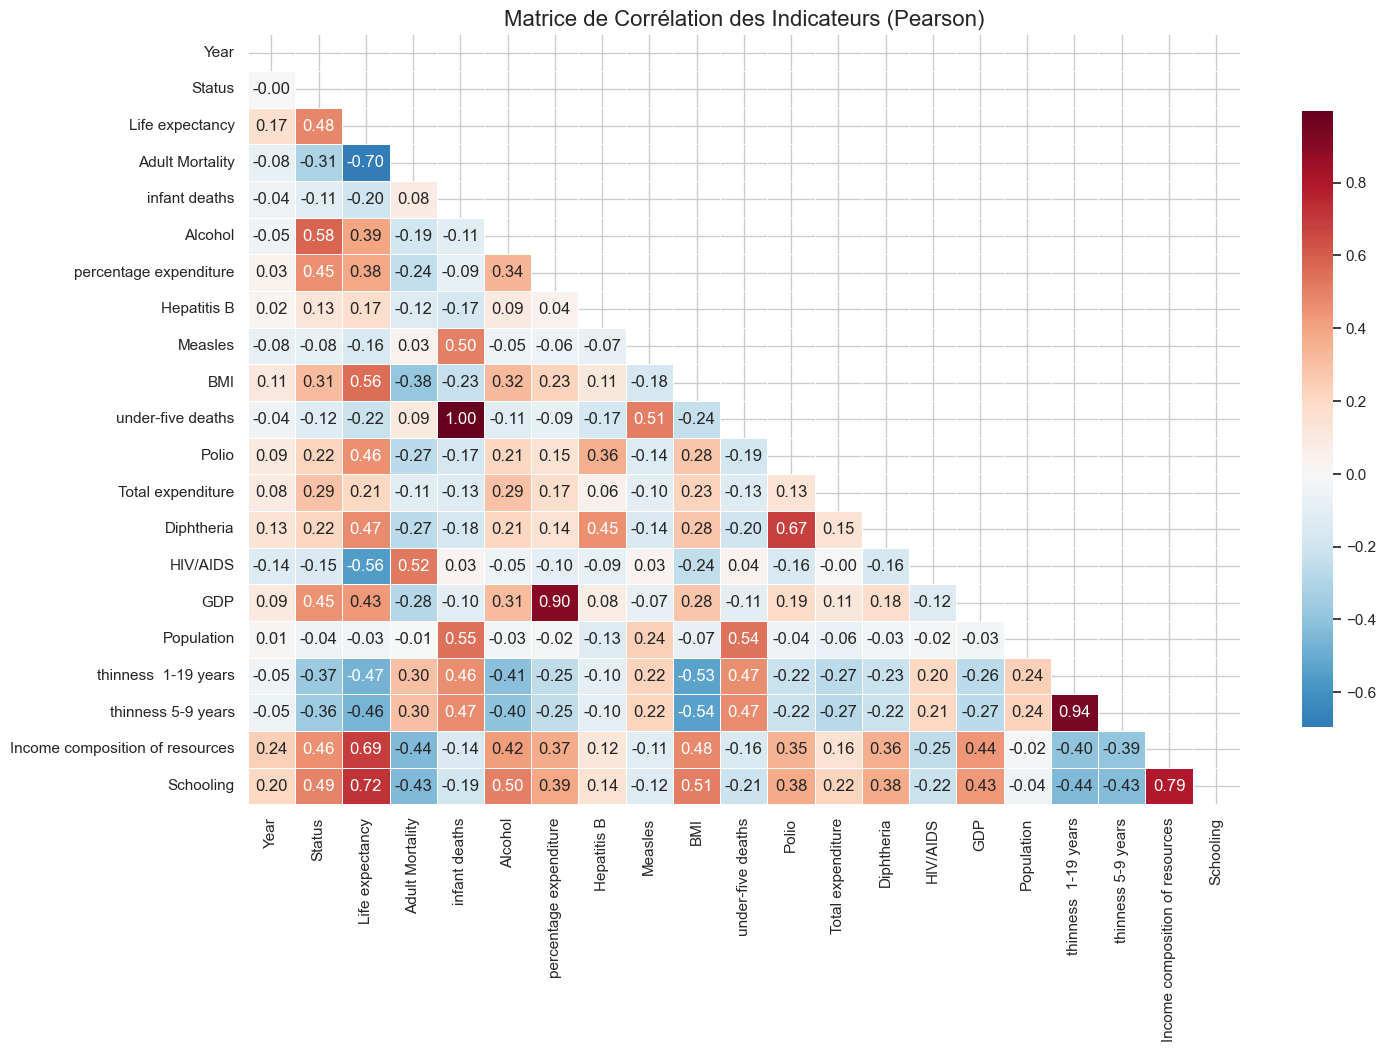

In [8]:
# 1. Calcul de la matrice de corrélation (uniquement pour les variables numériques)
corr_matrix = df.corr(numeric_only=True)

# 2. Préparation de la figure
plt.figure(figsize=(16, 10))

# Masquer la partie supérieure pour une meilleure lisibilité
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 3. Génération de la Heatmap
sns.heatmap(corr_matrix, 
            mask=mask, 
            annot=True, 
            fmt=".2f", 
            cmap='RdBu_r', # Palette de couleurs rouge-bleu
            center=0,
            linewidths=.5, 
            cbar_kws={"shrink": .8})

plt.title("Matrice de Corrélation des Indicateurs (Pearson)", fontsize=16)
plt.show()

---
### **VII. Analyse de la Multicolinéarité et Sélection Finale**

Suite à l'affichage de la matrice de corrélation, nous avons identifié quatre paires de variables présentant une forte dépendance (Corrélation $\geq 0.80$). Pour optimiser les performances de notre modèle et éviter la redondance, nous appliquons la règle de suppression du candidat ayant la corrélation la plus faible avec la cible (`Life expectancy`).

#### **Décisions de suppression :**
1. **`infant deaths`** (r=1.00 avec `under-five deaths`) : Redondance totale.
2. **`percentage expenditure`** (r=0.90 avec `GDP`) : Le PIB est un indicateur plus robuste.
3. **`thinness 5-9 years`** (r=0.94 avec `thinness 1-19 years`) : Information couverte par la plage d'âge plus large.
4. **`Income composition of resources`** (r=0.80 avec `Schooling`) : Bien que les deux soient importants, la scolarisation montre un lien statistique plus fort avec la longévité.

   **En supprimant également la variable `Country` (comme justifié précédemment), nous réduisons le bruit et simplifions la structure du modèle.**
---

In [9]:
# 1. Liste des colonnes à supprimer après analyse approfondie
cols_finales_a_supprimer = [
    'Country', 
    'infant deaths', 
    'percentage expenditure', 
    'thinness 5-9 years', 
    'Income composition of resources'
]

# 2. Suppression groupée
df.drop(columns=[c for c in cols_finales_a_supprimer if c in df.columns], inplace=True)

# 3. Résultat
print(f"Nettoyage terminé. Colonnes supprimées : {cols_finales_a_supprimer}")
print(f"Nombre de variables restantes pour le modèle : {df.shape[1]}")
print("-" * 30)
display(df.head())

Nettoyage terminé. Colonnes supprimées : ['Country', 'infant deaths', 'percentage expenditure', 'thinness 5-9 years', 'Income composition of resources']
Nombre de variables restantes pour le modèle : 17
------------------------------


,Year,Status,Life expectancy,Adult Mortality,Alcohol,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,Schooling
0,2015.0,0,65.0,263.0,0.01,65.0,1154.0,19.1,83.0,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,10.1
1,2014.0,0,59.9,271.0,0.01,62.0,492.0,18.6,86.0,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,10.0
2,2013.0,0,59.9,268.0,0.01,64.0,430.0,18.1,89.0,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,9.9
3,2012.0,0,59.5,272.0,0.01,67.0,2787.0,17.6,93.0,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,9.8
4,2011.0,0,59.2,275.0,0.01,68.0,3013.0,17.2,97.0,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,9.5


---
### **VIII. Stratégie de Modélisation et Étude Comparative**

Pour évaluer l'impact des traitements statistiques sur la performance de nos algorithmes, nous avons décidé d'adopter une approche expérimentale. 

**Nous allons comparer deux scénarios :**
1. **Scénario A (Baseline) :** Entraînement des modèles sur les données nettoyées mais conservant les valeurs aberrantes (outliers).
2. **Scénario B (Optimisé) :** Entraînement des modèles après traitement des outliers via la méthode IQR (Capping).

   **Objectif :** Déterminer si la suppression du "bruit" statistique améliore significativement la précision des prédictions ou si elle entraîne une perte d'information cruciale.
---

---
###  Conclusion de l'Étape 0 : État final du Dataset**

À l'issue de ce prétraitement, nous avons atteint les objectifs suivants :
* **Intégrité :** Aucune valeur manquante ne subsiste (Imputation hybride).
* **Numérisation :** Toutes les variables sont désormais exploitables numériquement (Encodage de `Status`).
* **Optimisation :** La multicolinéarité a été traitée en supprimant les variables redondantes.

    **Le dataset est désormais "Model-Ready". Nous pouvons maintenant passer à l'Étape 1 : Préparation à l'Apprentissage (Splitting & Scaling).**
---

# **Étape 1 : Préparation à l'Apprentissage (Splitting & Scaling)**

Une fois le nettoyage terminé, nous entrons dans la phase de préparation technique. L'objectif ici est de transformer notre dataset "Model-Ready" en structures mathématiques exploitables par les algorithmes de Machine Learning. 

Cette étape se concentre sur le **Scénario A** (Données avec outliers) pour établir notre modèle de référence (Baseline).

#### **Objectifs de cette étape :**
1. **Séparation (Splitting) :** Isoler la variable cible (`Life expectancy`) des variables explicatives.
2. **Division (Train/Test Split) :** Créer un ensemble d'entraînement pour l'apprentissage et un ensemble de test pour l'évaluation.
3. **Mise à l'échelle (Feature Scaling) :** Normaliser les ordres de grandeur des différentes variables.

In [10]:
# 1. Définition des Features (X) et de la Target (y)
# Nous utilisons le dataset nettoyé issu de l'étape 0
X = df.drop(columns=['Life expectancy'])
y = df['Life expectancy']

# 2. Division en ensemble d'entraînement (80%) et de test (20%)
# random_state=42 est utilisé pour garantir la reproductibilité des résultats
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Dimensions de X_train : {X_train.shape}")
print(f"Dimensions de X_test : {X_test.shape}")
print("Division des données effectuée avec succès.")

Dimensions de X_train : (2350, 16)
Dimensions de X_test : (588, 16)
Division des données effectuée avec succès.


#### **Note Technique : Pourquoi choisir le StandardScaler ?**

Pour ce projet, nous avons opté pour le **StandardScaler** (Standardization) au lieu du **MinMaxScaler** (Normalization) pour les raisons suivantes :

1. **Robustesse aux Outliers :** Contrairement au `MinMaxScaler` qui compresse les données dans un intervalle fixe [0,1] et se laisse influencer par les valeurs extrêmes, le `StandardScaler` centre les données autour d'une moyenne de 0 avec un écart-type de 1.
2. **Préservation de la Distribution :** Il maintient mieux la forme de la distribution originale, ce qui est essentiel puisque nous avons choisi de conserver les outliers pour notre premier scénario d'étude.
3. **Efficacité Algorithmique :** La majorité des modèles de régression (comme la Régression Linéaire) convergent plus rapidement et plus efficacement lorsque les features sont standardisées.

In [11]:
# 1. Initialisation du Scaler
scaler = StandardScaler()

# 2. Ajustement et transformation sur X_train
# On apprend les paramètres (moyenne, écart-type) uniquement sur le Train Set
X_train_scaled = scaler.fit_transform(X_train)

# 3. Transformation sur X_test
# On applique la même transformation SANS ré-ajuster pour éviter le Data Leakage
X_test_scaled = scaler.transform(X_test)

print("Mise à l'échelle (Feature Scaling) terminée.")
# Affichage d'un exemple des données transformées
print("Exemple de données standardisées (X_train_scaled[0]) :\n", X_train_scaled[0])

Mise à l'échelle (Feature Scaling) terminée.
Exemple de données standardisées (X_train_scaled[0]) :
 [-0.11655742 -0.46310937 -0.31789671  0.17610231  0.56335458 -0.20010986
 -0.65421081 -0.26221474  0.65421795 -0.67947813  0.65566951 -0.2254545
 -0.26012434 -0.18771859  0.75727771 -0.03879636]


---
#### **Conclusion de l'Étape 1**

Les données sont désormais divisées et mises à l'échelle. Nous disposons de quatre ensembles de données prêts pour la modélisation :
* `X_train_scaled` & `y_train` : Pour l'entraînement du modèle.
* `X_test_scaled` & `y_test` : Pour l'évaluation finale.

  **Nous sommes maintenant prêts à passer à l'Étape 2 : Modélisation et Entraînement (Scénario A).**
---

# **Étape 2 : Modélisation et Comparaison des Scénarios (Baseline)**

Dans cette étape, nous allons construire notre premier modèle de prédiction en utilisant la **Régression Linéaire**. L'objectif principal est de comparer deux approches pour déterminer laquelle offre la meilleure précision :

* **Scénario A :** Utilisation du dataset complet (avec outliers).
* **Scénario B :** Utilisation d'un dataset nettoyé des valeurs aberrantes (outliers).

Cette comparaison nous permettra de valider scientifiquement notre stratégie de prétraitement avant d'explorer des modèles plus complexes.

### **I. Préparation des Données du Scénario B (Nettoyage des Outliers)**

In [12]:
# 1. Création d'une copie pour le Scénario B
df_scenario_B = df.copy()

# 2. Identification et suppression des outliers via la méthode IQR
# Nous appliquons cela sur les variables numériques clés
cols_outliers = ['Adult Mortality', 'HIV/AIDS', 'GDP', 'Population']

for col in cols_outliers:
    Q1 = df_scenario_B[col].quantile(0.25)
    Q3 = df_scenario_B[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Suppression des lignes hors limites
    df_scenario_B = df_scenario_B[(df_scenario_B[col] >= lower_bound) & (df_scenario_B[col] <= upper_bound)]

print(f"Taille du dataset A (Original) : {df.shape[0]} lignes")
print(f"Taille du dataset B (Sans Outliers) : {df_scenario_B.shape[0]} lignes")

Taille du dataset A (Original) : 2938 lignes
Taille du dataset B (Sans Outliers) : 1649 lignes


In [13]:
# Préparation des données pour le Scénario B
X_B = df_scenario_B.drop(columns=['Life expectancy'])
y_B = df_scenario_B['Life expectancy']

X_train_B, X_test_B, y_train_B, y_test_B = train_test_split(X_B, y_B, test_size=0.2, random_state=42)

# Scaling pour le Scénario B
scaler_B = StandardScaler()
X_train_B_scaled = scaler_B.fit_transform(X_train_B)
X_test_B_scaled = scaler_B.transform(X_test_B)

print("Préparation du Scénario B terminée.")

Préparation du Scénario B terminée.


### **II. Entraînement et Évaluation Comparative (A vs B)**

In [14]:
# --- Entraînement Scénario A ---
model_A = LinearRegression()
model_A.fit(X_train_scaled, y_train) 
y_pred_A = model_A.predict(X_test_scaled)

# --- Entraînement Scénario B ---
model_B = LinearRegression()
model_B.fit(X_train_B_scaled, y_train_B)
y_pred_B = model_B.predict(X_test_B_scaled)

# --- Calcul des Métriques ---
r2_A = r2_score(y_test, y_pred_A)
rmse_A = np.sqrt(mean_squared_error(y_test, y_pred_A))

r2_B = r2_score(y_test_B, y_pred_B)
rmse_B = np.sqrt(mean_squared_error(y_test_B, y_pred_B))

print(f"Résultats Scénario A (Avec Outliers) : R² = {r2_A:.4f}, RMSE = {rmse_A:.4f}")
print(f"Résultats Scénario B (Sans Outliers) : R² = {r2_B:.4f}, RMSE = {rmse_B:.4f}")

Résultats Scénario A (Avec Outliers) : R² = 0.8108, RMSE = 4.0487
Résultats Scénario B (Sans Outliers) : R² = 0.6524, RMSE = 3.5061


---
### **III. Visualisation de l'Ajustement : Valeurs Réelles vs Prédites**

Pour visualiser comment le modèle "s'ajuste" aux données, nous traçons les valeurs prédites par le modèle en fonction des valeurs réelles. 

* La ligne diagonale en pointillés représente la **prédiction parfaite** (où la valeur prédite est égale à la valeur réelle).
* Plus les points sont proches de cette ligne, meilleur est le modèle. Cela nous permettra de voir visuellement où le Scénario A et le Scénario B réussissent ou échouent.
---

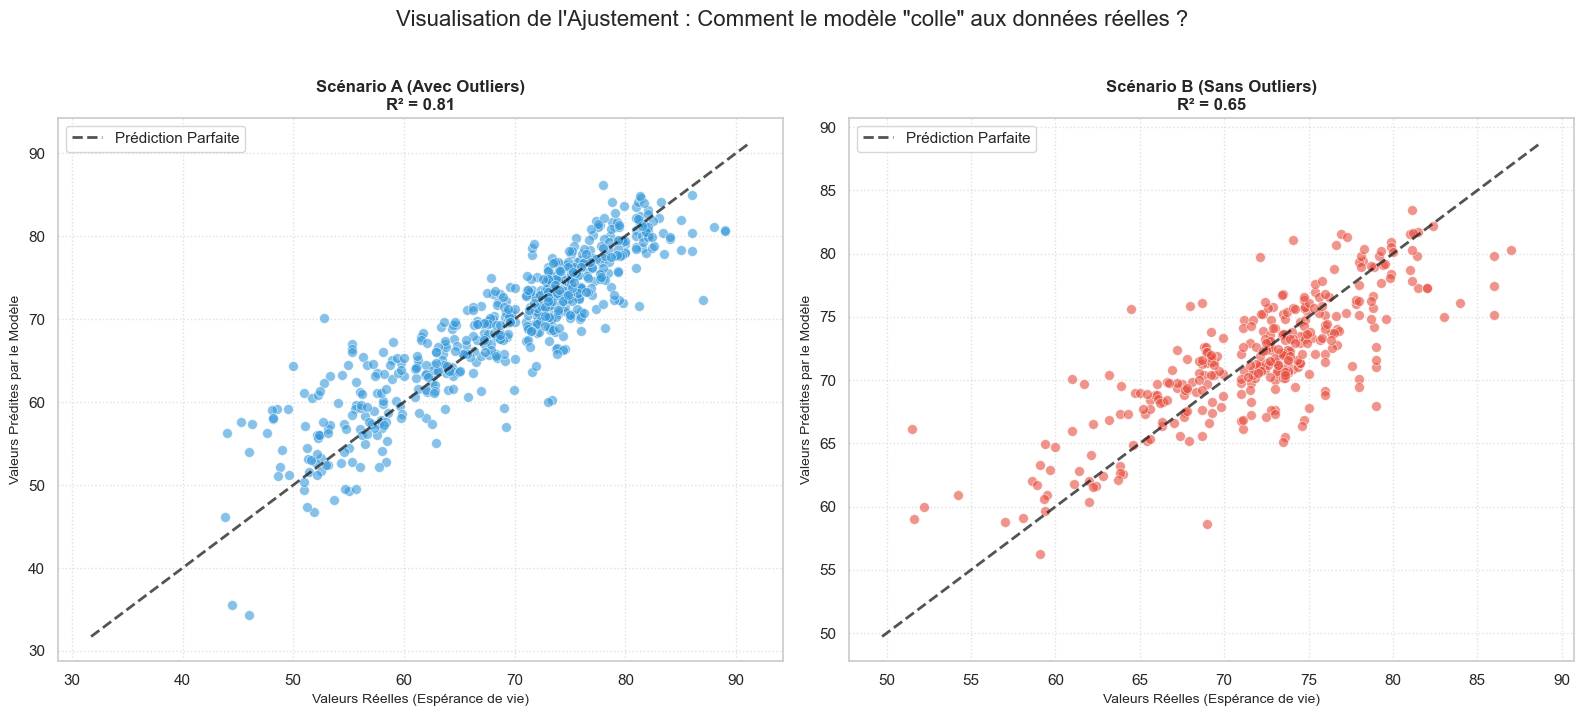

In [15]:
# Création de la figure avec deux sous-graphiques
fig, ax = plt.subplots(1, 2, figsize=(16, 7))

# --- Graphique 1 : Scénario A (Avec Outliers) ---
# Nuage de points : Réel vs Prédit
sns.scatterplot(x=y_test, y=y_pred_A, ax=ax[0], color='#3498db', alpha=0.6, s=50)

# Ajout de la ligne de référence (Diagonale parfaite)
# On prend les limites min et max pour tracer la ligne y = x
limits_A = [np.min([ax[0].get_xlim(), ax[0].get_ylim()]),
            np.max([ax[0].get_xlim(), ax[0].get_ylim()])]
ax[0].plot(limits_A, limits_A, 'k--', alpha=0.75, linewidth=2, label='Prédiction Parfaite')

# Titres et labels
ax[0].set_title(f'Scénario A (Avec Outliers)\nR² = {r2_A:.2f}', fontsize=12, fontweight='bold')
ax[0].set_xlabel('Valeurs Réelles (Espérance de vie)', fontsize=10)
ax[0].set_ylabel('Valeurs Prédites par le Modèle', fontsize=10)
ax[0].legend()
ax[0].grid(True, linestyle=':', alpha=0.6)

# --- Graphique 2 : Scénario B (Sans Outliers) ---
# Nuage de points : Réel vs Prédit
sns.scatterplot(x=y_test_B, y=y_pred_B, ax=ax[1], color='#e74c3c', alpha=0.6, s=50)

# Ajout de la ligne de référence (Diagonale parfaite)
limits_B = [np.min([ax[1].get_xlim(), ax[1].get_ylim()]),
            np.max([ax[1].get_xlim(), ax[1].get_ylim()])]
ax[1].plot(limits_B, limits_B, 'k--', alpha=0.75, linewidth=2, label='Prédiction Parfaite')

# Titres et labels
ax[1].set_title(f'Scénario B (Sans Outliers)\nR² = {r2_B:.2f}', fontsize=12, fontweight='bold')
ax[1].set_xlabel('Valeurs Réelles (Espérance de vie)', fontsize=10)
ax[1].set_ylabel('Valeurs Prédites par le Modèle', fontsize=10)
ax[1].legend()
ax[1].grid(True, linestyle=':', alpha=0.6)

# Titre global
plt.suptitle('Visualisation de l\'Ajustement : Comment le modèle "colle" aux données réelles ?', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

---
### **Analyse Visuelle et Décision Stratégique**

L'observation des graphiques "Réel vs Prédit" est très instructive :

1.  **Scénario A (Gauche) :** Les points sont globalement bien regroupés autour de la ligne diagonale, ce qui explique le $R^2$ élevé (0.81). Le modèle parvient à capturer la tendance générale même avec la présence de points extrêmes.
2.  **Scénario B (Droite) :** Bien que les données semblent plus "propres" (moins dispersées), le nuage de points est plus diffus et s'éloigne davantage de la ligne parfaite, surtout pour les valeurs faibles d'espérance de vie. Le modèle a perdu sa capacité à bien prédire sur toute la gamme de données.

 * **Décision Finale :** Ces graphiques confirment que le **Scénario A** offre un meilleur ajustement global à la réalité complexe des données. Nous poursuivons donc avec ce scénario.
---

# **Étape 3 : Modèles Avancés et Optimisation**

Dans cette étape, nous explorons des algorithmes non-linéaires pour tenter de surpasser la performance de notre modèle de référence. Nous utilisons exclusivement le **Scénario A** (données avec outliers), validé précédemment pour sa meilleure représentativité.

#### **Objectifs de cette étape :**
1.  **Optimisation de KNN :** Trouver le nombre de voisins ($K$) idéal pour maximiser la précision.
2.  **Modélisation par Arbre de Décision :** Évaluer la capacité d'un modèle non-paramétrique à capturer les relations complexes entre les indicateurs de santé.

---
### **I. K-Nearest Neighbors (KNN Regressor)**

    Le modèle KNN prédit l'espérance de vie en se basant sur la moyenne des pays les plus "proches" statistiquement. Pour garantir une performance optimale, nous effectuons une recherche itérative (Loop) sur le paramètre K.
---

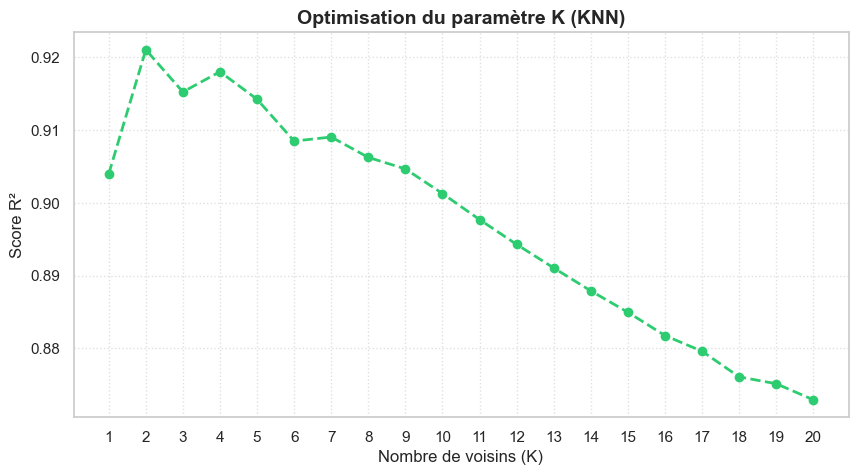

Meilleure valeur : K = 2
Performance KNN : R² = 0.9211, RMSE = 2.6152


In [16]:
# Test de plusieurs valeurs de K (de 1 à 20) pour trouver l'optimum
k_values = range(1, 21)
r2_scores_knn = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    r2_scores_knn.append(knn.score(X_test_scaled, y_test))

# Visualisation de la courbe d'optimisation
plt.figure(figsize=(10, 5))
plt.plot(k_values, r2_scores_knn, marker='o', linestyle='--', color='#2ecc71', linewidth=2)
plt.title("Optimisation du paramètre K (KNN)", fontsize=14, fontweight='bold')
plt.xlabel("Nombre de voisins (K)")
plt.ylabel("Score R²")
plt.xticks(k_values)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# Extraction des meilleurs résultats
best_k = k_values[np.argmax(r2_scores_knn)]
best_r2_knn = max(r2_scores_knn)

# Entraînement du modèle final avec le meilleur K
final_knn = KNeighborsRegressor(n_neighbors=best_k)
final_knn.fit(X_train_scaled, y_train)
y_pred_knn = final_knn.predict(X_test_scaled)
rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))

print(f"Meilleure valeur : K = {best_k}")
print(f"Performance KNN : R² = {best_r2_knn:.4f}, RMSE = {rmse_knn:.4f}")

---
### **II. Decision Tree Regressor (Arbre de Décision)**

    Contrairement aux modèles linéaires, l'arbre de décision segmente les données en sous-groupes homogènes. C'est un modèle puissant pour capturer des interactions non-linéaires entre les variables explicatives.
---

In [17]:
# Initialisation du modèle (on limite la profondeur pour éviter l'Overfitting)
dt_model = DecisionTreeRegressor(max_depth=10, random_state=42)

# Entraînement
dt_model.fit(X_train_scaled, y_train)

# Prédiction et Évaluation
y_pred_dt = dt_model.predict(X_test_scaled)
r2_dt = r2_score(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))

print(f"Performance Decision Tree : R² = {r2_dt:.4f}, RMSE = {rmse_dt:.4f}")

Performance Decision Tree : R² = 0.9268, RMSE = 2.5186


---
### **Interprétation des Résultats de l'Étape 3**

L'implémentation des modèles non-linéaires a radicalement transformé la précision de nos prédictions :

1. **KNN (K=2) :** Malgré une valeur de K très faible, le modèle atteint un $R^2$ de **0.9211**. Cela démontre une forte corrélation locale entre les indicateurs de pays similaires. En régression, l'utilisation d'un K pair n'est pas problématique car le modèle calcule une moyenne pondérée et non un vote majoritaire.
2. **Decision Tree (Profondeur=10) :** C'est notre modèle le plus performant avec un $R^2$ de **0.9268**. La capacité de l'arbre à segmenter les données de manière non-linéaire permet de capturer des interactions complexes que la Régression Linéaire ne pouvait pas percevoir.

   **Constat Global :** La nette supériorité de KNN et Decision Tree par rapport à la Régression Linéaire (0.81) confirme que les déterminants de l'espérance de vie mondiale suivent des schémas complexes et non-linéaires.
---

# **Étape 4 : Synthèse et Comparaison Finale**

Cette étape ultime consiste à confronter les performances de tous les modèles testés au cours du projet. En regroupant les métriques de précision ($R^2$) et d'erreur ($RMSE$), nous allons identifier l'algorithme le plus fiable pour prédire l'espérance de vie mondiale.

#### **Objectifs :**
1. **Tableau Récapitulatif :** Consolider les résultats des trois modèles.
2. **Comparaison Graphique :** Visualiser l'évolution de la performance.
3. **Sélection du Modèle Champion :** Désigner la meilleure solution pour ce dataset.

--- Tableau Récapitulatif des Performances ---


,Modèle,Score R²,Erreur RMSE
0,Régression Linéaire,0.8108,4.0487
1,K-Nearest Neighbors (KNN),0.9211,2.6152
2,Arbre de Décision,0.9268,2.5186


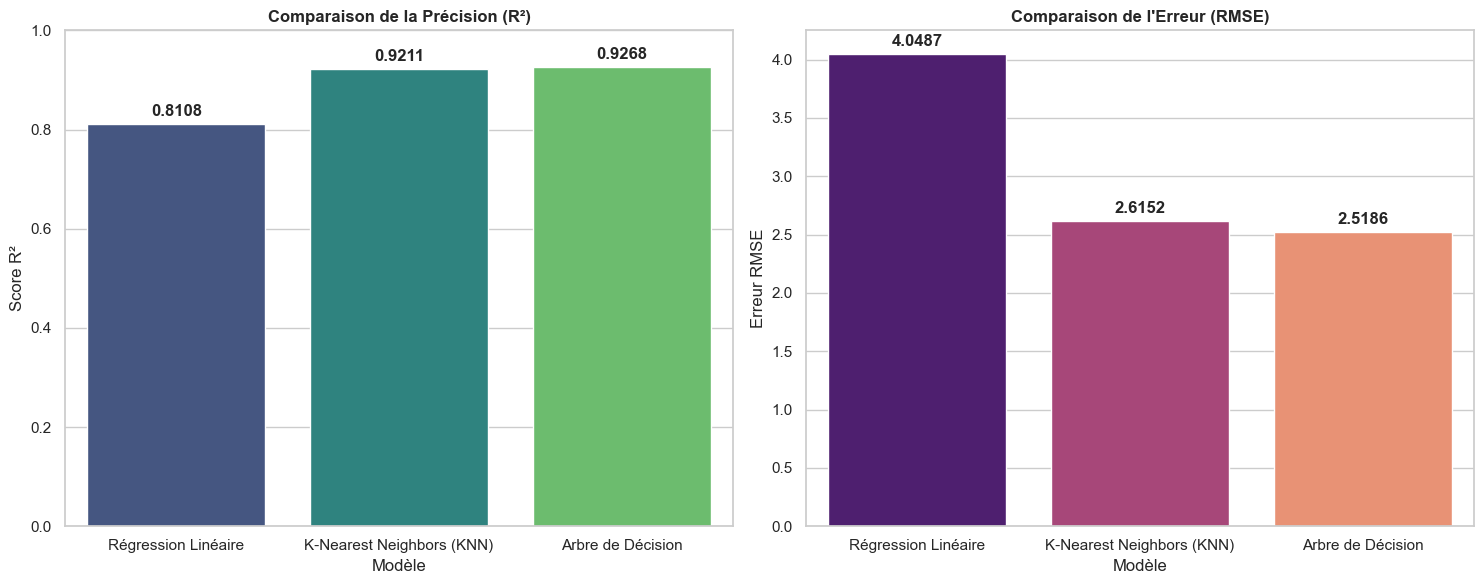

In [18]:
# 1. Création du tableau de comparaison
data_results = {
    'Modèle': ['Régression Linéaire', 'K-Nearest Neighbors (KNN)', 'Arbre de Décision'],
    'Score R²': [0.8108, 0.9211, 0.9268],
    'Erreur RMSE': [4.0487, 2.6152, 2.5186]
}

df_comparison = pd.DataFrame(data_results)

# Affichage du tableau
print("--- Tableau Récapitulatif des Performances ---")
display(df_comparison)

# 2. Visualisation Graphique
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Graphique du Score R² (Plus haut est mieux)
sns.barplot(x='Modèle', y='Score R²', data=df_comparison, ax=ax[0], palette='viridis')
ax[0].set_title('Comparaison de la Précision (R²)', fontweight='bold')
ax[0].set_ylim(0, 1)
for p in ax[0].patches:
    ax[0].annotate(f'{p.get_height():.4f}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontweight='bold')

# Graphique de l'Erreur RMSE (Plus bas est mieux)
sns.barplot(x='Modèle', y='Erreur RMSE', data=df_comparison, ax=ax[1], palette='magma')
ax[1].set_title('Comparaison de l\'Erreur (RMSE)', fontweight='bold')
for p in ax[1].patches:
    ax[1].annotate(f'{p.get_height():.4f}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()

---
### **Désignation du Modèle Champion**

Après analyse des résultats, le modèle **Arbre de Décision (Decision Tree)** est déclaré vainqueur de cette étude.

* **Performance :** Il atteint le score $R^2$ le plus élevé (**0.9268**) et l'erreur la plus faible (**2.5186**).
* **Justification :** Sa capacité à diviser les données en segments logiques lui permet de mieux s'adapter aux disparités entre pays développés et pays en développement, là où la Régression Linéaire restait trop rigide.
---

# **Conclusion Générale du Projet**

Ce projet nous a permis de traverser tout le cycle de vie d'une étude de Data Science, du nettoyage des données jusqu'à l'optimisation des modèles prédictifs.

**Points clés à retenir :**
1. **L'importance du Diagnostic :** Nous avons prouvé que les outliers dans ce dataset ne sont pas des erreurs mais des données essentielles pour la précision.
2. **Non-linéarité :** L'espérance de vie dépend d'interactions complexes entre la santé, l'économie et l'éducation, ce qui rend les modèles comme les Arbres de Décision particulièrement efficaces.
3. **Recommandation :** Pour améliorer encore ce modèle, l'ajout de données temporelles ou géopolitiques plus récentes pourrait permettre une meilleure anticipation des crises sanitaires futures.


In [19]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import pandas as pd
import numpy as np

# 1. Création des champs de saisie (Widgets) pour chaque caractéristique
style = {'description_width': 'initial'}
layout = widgets.Layout(width='450px')

# Configuration des widgets de saisie
year_w = widgets.IntSlider(value=2015, min=2000, max=2020, description='Année :', style=style, layout=layout)
status_w = widgets.Dropdown(options=[('En développement', 0), ('Développé', 1)], value=0, description='Statut du pays :', style=style, layout=layout)
adult_mortality_w = widgets.FloatText(value=263.0, description='Mortalité Adulte :', style=style, layout=layout)
alcohol_w = widgets.FloatText(value=0.01, description='Consommation d\'Alcool :', style=style, layout=layout)
hepatitis_b_w = widgets.FloatText(value=65.0, description='Hépatite B (%) :', style=style, layout=layout)
measles_w = widgets.FloatText(value=1154.0, description='Rougeole (cas) :', style=style, layout=layout)
bmi_w = widgets.FloatText(value=19.1, description='Indice IMC (BMI) :', style=style, layout=layout)
under_five_deaths_w = widgets.FloatText(value=83.0, description='Décès < 5 ans :', style=style, layout=layout)
polio_w = widgets.FloatText(value=6.0, description='Polio (%) :', style=style, layout=layout)
total_expenditure_w = widgets.FloatText(value=8.16, description='Dépenses Totales :', style=style, layout=layout)
diphtheria_w = widgets.FloatText(value=65.0, description='Diphtérie (%) :', style=style, layout=layout)
hiv_aids_w = widgets.FloatText(value=0.1, description='Taux VIH/SIDA :', style=style, layout=layout)
gdp_w = widgets.FloatText(value=584.25, description='PIB par habitant :', style=style, layout=layout)
population_w = widgets.FloatText(value=33736494.0, description='Population :', style=style, layout=layout)
thinness_1_19_w = widgets.FloatText(value=17.2, description='Minceur 1-19 ans :', style=style, layout=layout)
schooling_w = widgets.FloatText(value=10.1, description='Scolarité (années) :', style=style, layout=layout)

# Bouton de prédiction
predict_button = widgets.Button(
    description="Prédire l'Espérance de Vie", 
    button_style='success', 
    layout=widgets.Layout(width='910px', height='40px')
)
output_area = widgets.Output()

# 2. Fonction de gestion du clic sur le bouton
def on_predict_clicked(b):
    with output_area:
        clear_output()
        try:
            # Collecte des données depuis l'interface (ordre strict des colonnes)
            data = {
                'Year': year_w.value,
                'Status': status_w.value,
                'Adult Mortality': adult_mortality_w.value,
                'Alcohol': alcohol_w.value,
                'Hepatitis B': hepatitis_b_w.value,
                'Measles': measles_w.value,
                'BMI': bmi_w.value,
                'under-five deaths': under_five_deaths_w.value,
                'Polio': polio_w.value,
                'Total expenditure': total_expenditure_w.value,
                'Diphtheria': diphtheria_w.value,
                'HIV/AIDS': hiv_aids_w.value,
                'GDP': gdp_w.value,
                'Population': population_w.value,
                'thinness  1-19 years': thinness_1_19_w.value, # Double espace conservé pour la cohérence
                'Schooling': schooling_w.value
            }
            
            # Conversion en DataFrame, Scaling et Prédiction
            input_df = pd.DataFrame([data])
            input_scaled = scaler.transform(input_df)
            prediction = dt_model.predict(input_scaled)[0]
            
            # Affichage du résultat final
            print(f"\n✅ Résultat du Modèle Champion (Decision Tree) :")
            print(f"👉 L'espérance de vie estimée est de : {prediction:.2f} ans")
            
        except Exception as e:
            print(f"⚠️ Erreur lors de la prédiction : {e}")

predict_button.on_click(on_predict_clicked)

# 3. Organisation de l'interface utilisateur (Layout)
col1 = widgets.VBox([year_w, status_w, adult_mortality_w, alcohol_w, hepatitis_b_w, measles_w, bmi_w, under_five_deaths_w])
col2 = widgets.VBox([polio_w, total_expenditure_w, diphtheria_w, hiv_aids_w, gdp_w, population_w, thinness_1_19_w, schooling_w])

ui = widgets.VBox([
    widgets.HTML("<h2 style='color: #2e7d32;'>🧪 Interface de Prédiction Interactive</h2>"),
    widgets.HBox([col1, col2]),
    predict_button,
    output_area
])

# Affichage de l'interface
display(ui)